  θ(t) built: 7742 daily points, 12 features

Computing velocity vectors (no smoothing for precision)...
Identifying jumps at multiple τ scales...
  τ = 80th pct (speed > 0.557): 647 jumps
  τ = 90th pct (speed > 0.779): 399 jumps
  τ = 95th pct (speed > 1.062): 220 jumps

Running directional precursor analysis...
Computing null model baseline...
  Null model: mean cosine sim = 0.006 ± 0.468

Plotting Figure 1...

Outputs saved to /outputs folder


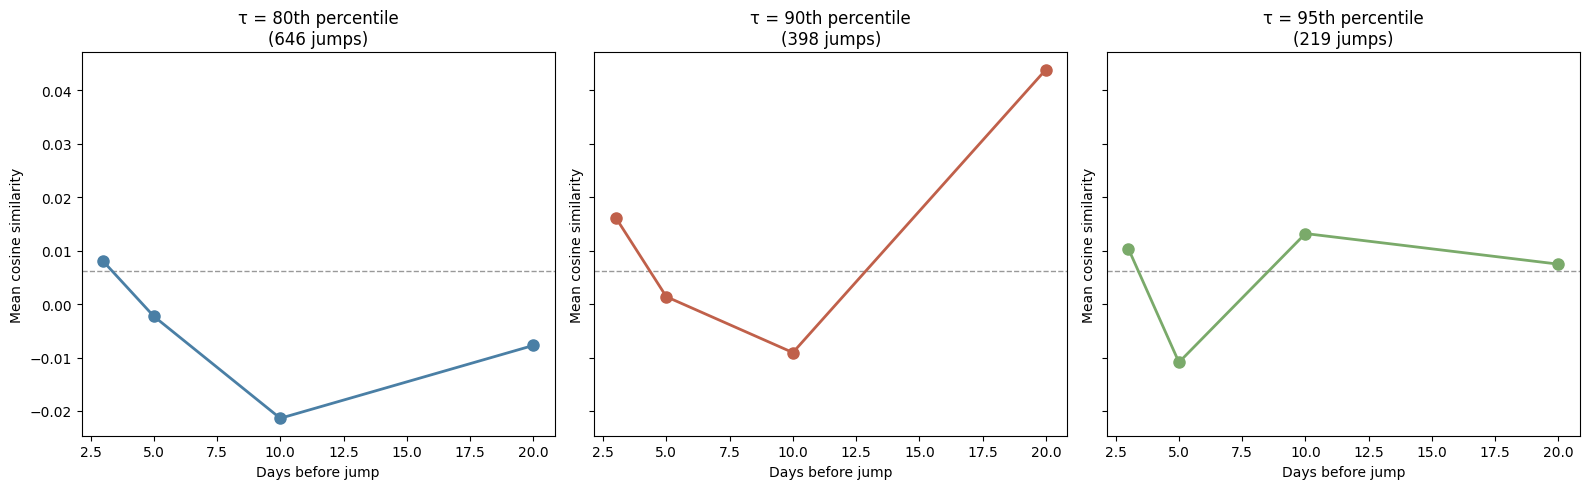

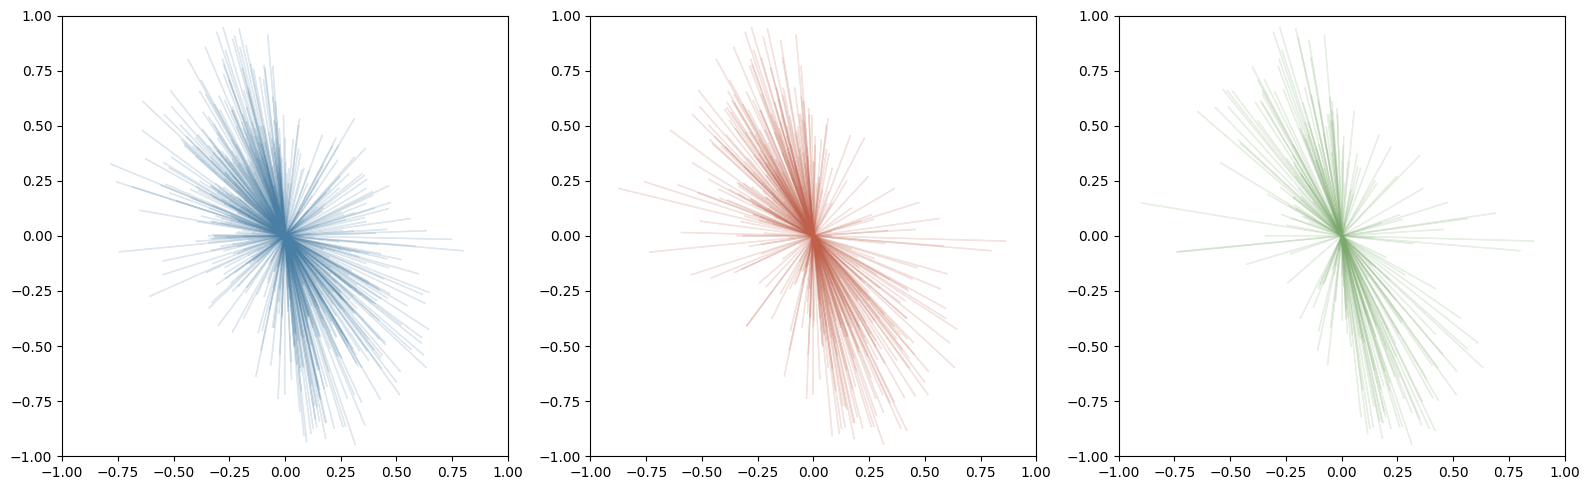

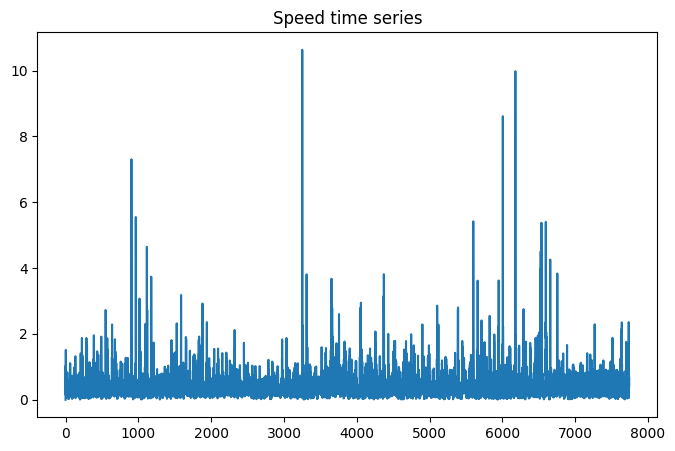

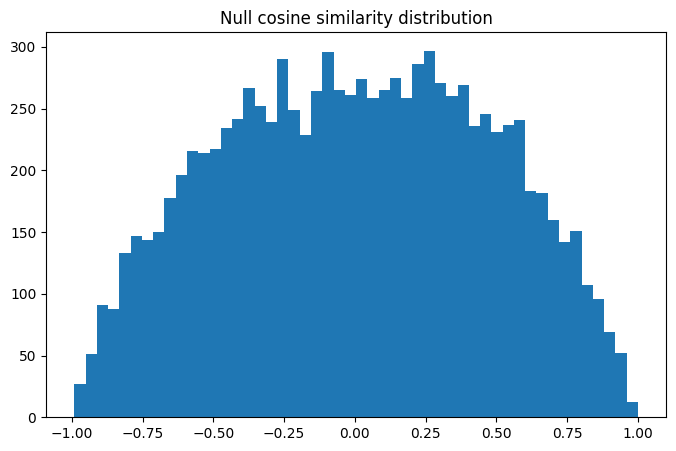

In [2]:
"""
Directional Precursor Analysis
================================
Core question: before a jump in theta(t), was the velocity vector
already pointing toward the dangerous direction?

If yes — direction of motion is an early warning signal that
precedes speed and acceleration spikes.

Run after regime_analysis.py — this builds on the same theta(t).
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm
from scipy.stats import circmean, circstd
from scipy.spatial.distance import cosine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import yfinance as yf
from scipy.stats import skew, kurtosis
from scipy.ndimage import uniform_filter1d
import os

# create outputs folder (fix for save path)
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

TICKER   = "^GSPC"
START    = "1994-01-01"
END      = "2024-12-31"
WINDOW   = 60
STEP     = 1

TAU_PERCENTILES = [80, 90, 95]
LOOKBACK_DAYS   = [3, 5, 10, 20]

# ─────────────────────────────────────────────
# 1. REBUILD theta(t)
# ─────────────────────────────────────────────

print("Downloading data and building θ(t)...")

raw      = yf.download(TICKER, start=START, end=END, progress=False)
prices   = raw["Close"].squeeze()
log_ret  = np.log(prices / prices.shift(1)).dropna()

def compute_theta(ret_window):
    r = ret_window.values
    ac = lambda x, lag: np.corrcoef(x[:-lag], x[lag:])[0,1] if len(x) > lag else 0.0
    cum = np.cumprod(1 + r)
    rm  = np.maximum.accumulate(cum)
    dd  = (cum - rm) / rm
    return {
        "mu":         np.mean(r),
        "sigma2":     np.var(r, ddof=1),
        "skewness":   skew(r),
        "kurtosis":   kurtosis(r),
        "ac1":        ac(r, 1),
        "ac2":        ac(r, 2),
        "ac5":        ac(r, 5),
        "vol_of_vol": np.std(np.abs(r), ddof=1),
        "semi_var":   np.var(r[r<0], ddof=1) if (r<0).sum() > 1 else 0.0,
        "mad":        np.mean(np.abs(r - np.mean(r))),
        "max_dd":     np.min(dd),
        "gl_ratio":   (np.mean(r[r>0]) / abs(np.mean(r[r<0])))
                       if (r<0).sum()>0 and (r>0).sum()>0 else 1.0,
    }

records, dates = [], []
for i in range(WINDOW, len(log_ret)):
    records.append(compute_theta(log_ret.iloc[i-WINDOW:i]))
    dates.append(log_ret.index[i])

theta_df   = pd.DataFrame(records, index=dates)
feat_cols  = list(theta_df.columns)

scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(theta_df.values)

pca        = PCA(n_components=min(6, len(feat_cols)))
X_pca      = pca.fit_transform(X_scaled)

print(f"  θ(t) built: {len(theta_df)} daily points, "
      f"{len(feat_cols)} features\n")

# ─────────────────────────────────────────────
# 2. VELOCITY
# ─────────────────────────────────────────────

print("Computing velocity vectors (no smoothing for precision)...")

V = np.diff(X_pca, axis=0, prepend=X_pca[[0]])
speed = np.linalg.norm(V, axis=1)

with np.errstate(invalid='ignore', divide='ignore'):
    V_unit = V / speed[:, None]
    V_unit = np.nan_to_num(V_unit, nan=0.0)

theta_df["speed"] = speed

# ─────────────────────────────────────────────
# 3. IDENTIFY JUMPS
# ─────────────────────────────────────────────

print("Identifying jumps at multiple τ scales...")

jump_sets = {}
for pct in TAU_PERCENTILES:
    tau          = np.percentile(speed, pct)
    jump_idx     = np.where(speed > tau)[0]
    clean = [jump_idx[0]]
    for j in jump_idx[1:]:
        if j - clean[-1] > 5:
            clean.append(j)
    jump_sets[pct] = np.array(clean)
    print(f"  τ = {pct}th pct (speed > {tau:.3f}): {len(clean)} jumps")

print()

# ─────────────────────────────────────────────
# 4. DIRECTIONAL PRECURSOR
# ─────────────────────────────────────────────

print("Running directional precursor analysis...")

results = {}

for pct, jump_idx in jump_sets.items():
    pct_results = {}

    for lb in LOOKBACK_DAYS:
        similarities = []
        precursor_dirs = []
        jump_dirs = []

        for j in jump_idx:
            if j < lb + 5 or j >= len(V_unit):
                continue

            jump_dir     = V_unit[j]
            precursor_dir = V_unit[j - lb]

            sim = 1 - cosine(jump_dir + 1e-10,
                             precursor_dir + 1e-10)

            similarities.append(sim)
            precursor_dirs.append(precursor_dir)
            jump_dirs.append(jump_dir)

        pct_results[lb] = {
            "similarities":    np.array(similarities),
            "mean_sim":        np.mean(similarities),
            "precursor_dirs":  np.array(precursor_dirs),
            "jump_dirs":       np.array(jump_dirs),
            "n":               len(similarities),
        }

    results[pct] = pct_results

# ─────────────────────────────────────────────
# 5. NULL MODEL
# ─────────────────────────────────────────────

print("Computing null model baseline...")

n_null = 10000
null_sims = []
rng    = np.random.default_rng(42)

for _ in range(n_null):
    i, j = rng.integers(50, len(V_unit), size=2)
    s = 1 - cosine(V_unit[i] + 1e-10, V_unit[j] + 1e-10)
    null_sims.append(s)

null_mean = np.mean(null_sims)
null_std  = np.std(null_sims)

print(f"  Null model: mean cosine sim = {null_mean:.3f} ± {null_std:.3f}\n")

# ─────────────────────────────────────────────
# FIGURE 1
# ─────────────────────────────────────────────

print("Plotting Figure 1...")

fig1, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

colors = ["#4a7fa5", "#c0604a", "#7aaa6a"]

for ax, (pct, pct_results), col in zip(axes, results.items(), colors):

    mean_sims = [pct_results[lb]["mean_sim"] for lb in LOOKBACK_DAYS]
    n_jumps   = pct_results[LOOKBACK_DAYS[0]]["n"]

    ax.axhline(null_mean, color="#999", lw=1, ls="--")

    ax.plot(LOOKBACK_DAYS, mean_sims, "o-", color=col, lw=2,
            markersize=8)

    ax.set_title(f"τ = {pct}th percentile\n({n_jumps} jumps)")
    ax.set_xlabel("Days before jump")
    ax.set_ylabel("Mean cosine similarity")

fig1.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dir_fig1_similarity.png", dpi=150, bbox_inches="tight")

# ─────────────────────────────────────────────
# FIGURE 2
# ─────────────────────────────────────────────

fig2, axes2 = plt.subplots(1,3,figsize=(16,5))

for ax, (pct, pct_results), col in zip(axes2, results.items(), colors):

    lb = 10
    data = pct_results[lb]

    if len(data["jump_dirs"]) == 0:
        continue

    jd = data["jump_dirs"][:, :2]

    for d in jd:
        ax.arrow(0,0,d[0],d[1],alpha=0.15,color=col)

    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

fig2.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dir_fig2_directions.png", dpi=150, bbox_inches="tight")

# ─────────────────────────────────────────────
# FIGURE 3
# ─────────────────────────────────────────────

fig3 = plt.figure(figsize=(8,5))
plt.plot(speed)
plt.title("Speed time series")

plt.savefig(f"{OUTPUT_DIR}/dir_fig3_speed_profile.png", dpi=150, bbox_inches="tight")

# ─────────────────────────────────────────────
# FIGURE 4
# ─────────────────────────────────────────────

fig4 = plt.figure(figsize=(8,5))
plt.hist(null_sims, bins=50)
plt.title("Null cosine similarity distribution")

plt.savefig(f"{OUTPUT_DIR}/dir_fig4_alignment_drift.png", dpi=150, bbox_inches="tight")

print("\nOutputs saved to /outputs folder")

In [ ]:
"""
Directional Precursor Analysis
================================
Core question: before a jump in theta(t), was the velocity vector
already pointing toward the dangerous direction?

If yes — direction of motion is an early warning signal that
precedes speed and acceleration spikes.

Run after regime_analysis.py — this builds on the same theta(t).
"""

import warnings
warnings.filterwarnings("ignore")
import os
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm
from scipy.stats import circmean, circstd
from scipy.spatial.distance import cosine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import yfinance as yf
from scipy.stats import skew, kurtosis
from scipy.ndimage import uniform_filter1d

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

TICKER   = "^GSPC"
START    = "1994-01-01"
END      = "2024-12-31"
WINDOW   = 60
STEP     = 1          # daily this time — we need fine resolution for precursors

TAU_PERCENTILES = [80, 90, 95]   # define jumps at multiple scales
LOOKBACK_DAYS   = [3, 5, 10, 20] # how far before jump to look for precursor

# ─────────────────────────────────────────────
# 1. REBUILD theta(t) at daily step
# ─────────────────────────────────────────────

print("Downloading data and building θ(t)...")

raw      = yf.download(TICKER, start=START, end=END, progress=False)
prices   = raw["Close"].squeeze()
log_ret  = np.log(prices / prices.shift(1)).dropna()

def compute_theta(ret_window):
    r = ret_window.values
    ac = lambda x, lag: np.corrcoef(x[:-lag], x[lag:])[0,1] if len(x) > lag else 0.0
    cum = np.cumprod(1 + r)
    rm  = np.maximum.accumulate(cum)
    dd  = (cum - rm) / rm
    return {
        "mu":         np.mean(r),
        "sigma2":     np.var(r, ddof=1),
        "skewness":   skew(r),
        "kurtosis":   kurtosis(r),
        "ac1":        ac(r, 1),
        "ac2":        ac(r, 2),
        "ac5":        ac(r, 5),
        "vol_of_vol": np.std(np.abs(r), ddof=1),
        "semi_var":   np.var(r[r<0], ddof=1) if (r<0).sum() > 1 else 0.0,
        "mad":        np.mean(np.abs(r - np.mean(r))),
        "max_dd":     np.min(dd),
        "gl_ratio":   (np.mean(r[r>0]) / abs(np.mean(r[r<0])))
                       if (r<0).sum()>0 and (r>0).sum()>0 else 1.0,
    }

records, dates = [], []
for i in range(WINDOW, len(log_ret)):
    records.append(compute_theta(log_ret.iloc[i-WINDOW:i]))
    dates.append(log_ret.index[i])

theta_df   = pd.DataFrame(records, index=dates)
feat_cols  = list(theta_df.columns)

scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(theta_df.values)

# PCA (keep all components for velocity in full space, 2D for viz)
pca        = PCA(n_components=min(6, len(feat_cols)))
X_pca      = pca.fit_transform(X_scaled)

print(f"  θ(t) built: {len(theta_df)} daily points, "
      f"{len(feat_cols)} features\n")


# ─────────────────────────────────────────────
# 2. VELOCITY IN PCA SPACE (daily, no smoothing)
# ─────────────────────────────────────────────

print("Computing velocity vectors (no smoothing for precision)...")

V = np.diff(X_pca, axis=0, prepend=X_pca[[0]])   # velocity in PCA space
speed = np.linalg.norm(V, axis=1)

# Unit direction vector (normalised velocity)
with np.errstate(invalid='ignore', divide='ignore'):
    V_unit = V / speed[:, None]
    V_unit = np.nan_to_num(V_unit, nan=0.0)

theta_df["speed"] = speed


# ─────────────────────────────────────────────
# 3. IDENTIFY JUMPS AT MULTIPLE SCALES
# ─────────────────────────────────────────────

print("Identifying jumps at multiple τ scales...")

jump_sets = {}
for pct in TAU_PERCENTILES:
    tau          = np.percentile(speed, pct)
    jump_idx     = np.where(speed > tau)[0]
    # remove consecutive jumps — keep only first of a cluster
    clean = [jump_idx[0]]
    for j in jump_idx[1:]:
        if j - clean[-1] > 5:   # at least 5 days apart
            clean.append(j)
    jump_sets[pct] = np.array(clean)
    print(f"  τ = {pct}th pct (speed > {tau:.3f}): {len(clean)} jumps")

print()


# ─────────────────────────────────────────────
# 4. CORE ANALYSIS — DIRECTIONAL PRECURSOR
# ─────────────────────────────────────────────
# For each jump, extract V_unit at t-k for k in LOOKBACK_DAYS
# Then ask: do pre-jump directions cluster?
# Metric: cosine similarity between pre-jump velocity and
#         the velocity AT the jump (the "dangerous direction")

print("Running directional precursor analysis...")

results = {}

for pct, jump_idx in jump_sets.items():
    pct_results = {}

    for lb in LOOKBACK_DAYS:
        similarities = []
        precursor_dirs = []
        jump_dirs = []

        for j in jump_idx:
            if j < lb + 5 or j >= len(V_unit):
                continue

            jump_dir     = V_unit[j]               # direction AT jump
            precursor_dir = V_unit[j - lb]          # direction lb days before

            # Cosine similarity — 1 = same direction, -1 = opposite
            sim = 1 - cosine(jump_dir + 1e-10,
                             precursor_dir + 1e-10)
            similarities.append(sim)
            precursor_dirs.append(precursor_dir)
            jump_dirs.append(jump_dir)

        pct_results[lb] = {
            "similarities":    np.array(similarities),
            "mean_sim":        np.mean(similarities),
            "precursor_dirs":  np.array(precursor_dirs),
            "jump_dirs":       np.array(jump_dirs),
            "n":               len(similarities),
        }

    results[pct] = pct_results


# ─────────────────────────────────────────────
# 5. NULL MODEL — random cosine similarity baseline
# ─────────────────────────────────────────────

print("Computing null model baseline...")

n_null = 10000
null_sims = []
rng    = np.random.default_rng(42)
for _ in range(n_null):
    i, j = rng.integers(50, len(V_unit), size=2)
    s = 1 - cosine(V_unit[i] + 1e-10, V_unit[j] + 1e-10)
    null_sims.append(s)
null_mean = np.mean(null_sims)
null_std  = np.std(null_sims)
print(f"  Null model: mean cosine sim = {null_mean:.3f} ± {null_std:.3f}\n")


# ─────────────────────────────────────────────
# 6. FIGURE 1 — SIMILARITY VS LOOKBACK (main result)
# ─────────────────────────────────────────────

print("Plotting Figure 1: directional similarity vs lookback...")

fig1, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig1.suptitle(
    "Directional Precursor Test\n"
    "Does pre-jump velocity align with jump direction? (> null = predictive signal)",
    fontsize=12, fontweight="bold"
)

colors = ["#4a7fa5", "#c0604a", "#7aaa6a"]

for ax, (pct, pct_results), col in zip(axes, results.items(), colors):
    mean_sims = [pct_results[lb]["mean_sim"] for lb in LOOKBACK_DAYS]
    n_jumps   = pct_results[LOOKBACK_DAYS[0]]["n"]

    ax.axhline(null_mean, color="#999", lw=1, ls="--", label=f"Null baseline ({null_mean:.3f})")
    ax.axhspan(null_mean - null_std, null_mean + null_std,
               alpha=0.1, color="#999", label="Null ± 1σ")

    ax.plot(LOOKBACK_DAYS, mean_sims, "o-", color=col, lw=2,
            markersize=8, label=f"Mean cosine sim (n={n_jumps})")

    for lb, ms in zip(LOOKBACK_DAYS, mean_sims):
        z = (ms - null_mean) / null_std
        color_txt = "#2a6e2a" if ms > null_mean else "#c04040"
        ax.annotate(f"z={z:+.1f}", xy=(lb, ms),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=8, color=color_txt, fontweight="bold")

    ax.set_title(f"τ = {pct}th percentile\n({n_jumps} jumps)", fontsize=10)
    ax.set_xlabel("Days before jump (lookback)", fontsize=9)
    ax.set_ylabel("Mean cosine similarity to jump direction", fontsize=9)
    ax.set_xticks(LOOKBACK_DAYS)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

fig1.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dir_fig1_similarity.png", dpi=150, bbox_inches="tight")
print("  Saved dir_fig1_similarity.png")


# ─────────────────────────────────────────────
# 7. FIGURE 2 — PCA SPACE: jump directions + precursor directions
# ─────────────────────────────────────────────

print("Plotting Figure 2: jump directions in PCA space...")

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle(
    "Jump directions vs precursor directions in PC1–PC2 space\n"
    "(If arrows cluster → there is a consistent dangerous direction)",
    fontsize=11, fontweight="bold"
)

for ax, (pct, pct_results), col in zip(axes2, results.items(), colors):
    lb = 10   # use 10-day lookback for this viz
    data = pct_results[lb]

    if len(data["jump_dirs"]) == 0:
        ax.set_title(f"τ={pct}th — no data"); continue

    jd = data["jump_dirs"][:, :2]          # PC1-PC2 only
    pd_ = data["precursor_dirs"][:, :2]

    # Plot unit circle reference
    theta_circ = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta_circ), np.sin(theta_circ),
            color="#ddd", lw=0.5, zorder=0)

    # Plot individual jump directions (faint)
    for d in jd:
        ax.annotate("", xy=(d[0]*0.7, d[1]*0.7), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=col,
                                   alpha=0.15, lw=0.8))

    # Plot mean jump direction (bold)
    mean_jd = jd.mean(axis=0)
    mean_jd /= (np.linalg.norm(mean_jd) + 1e-10)
    ax.annotate("", xy=(mean_jd[0]*0.85, mean_jd[1]*0.85), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=col,
                                lw=2.5, label="mean jump dir"))
    ax.text(mean_jd[0]*0.92, mean_jd[1]*0.92, "mean\njump",
            ha="center", va="center", fontsize=7, color=col, fontweight="bold")

    # Plot mean precursor direction (dashed)
    mean_pd = pd_.mean(axis=0)
    mean_pd /= (np.linalg.norm(mean_pd) + 1e-10)
    ax.annotate("", xy=(mean_pd[0]*0.65, mean_pd[1]*0.65), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="#555",
                                lw=2, linestyle="dashed"))
    ax.text(mean_pd[0]*0.72, mean_pd[1]*0.72, f"mean\nprecursor\n(-{lb}d)",
            ha="center", va="center", fontsize=7, color="#555")

    # Angular spread of jump directions
    angles_j  = np.arctan2(jd[:, 1], jd[:, 0])
    spread    = np.degrees(circstd(angles_j))

    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")
    ax.axhline(0, color="#eee", lw=0.5)
    ax.axvline(0, color="#eee", lw=0.5)
    ax.set_xlabel("PC1 direction", fontsize=8)
    ax.set_ylabel("PC2 direction", fontsize=8)
    ax.set_title(f"τ={pct}th percentile\nAngular spread={spread:.0f}°  (lower=more clustered)",
                 fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig2.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dir_fig2_directions.png", dpi=150, bbox_inches="tight")
print("  Saved dir_fig2_directions.png")


# ─────────────────────────────────────────────
# 8. FIGURE 3 — SPEED PROFILE AROUND JUMPS
# ─────────────────────────────────────────────

print("Plotting Figure 3: average speed profile around jumps...")

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig3.suptitle(
    "Average speed profile around jump events\n"
    "(Does speed rise before the jump? How fast does it decay after?)",
    fontsize=11, fontweight="bold"
)

window_around = 20   # days before and after

for ax, (pct, jump_idx), col in zip(axes3, jump_sets.items(), colors):
    profiles = []
    for j in jump_idx:
        if j < window_around or j + window_around >= len(speed):
            continue
        profiles.append(speed[j - window_around : j + window_around + 1])

    if not profiles:
        continue

    profiles   = np.array(profiles)
    mean_prof  = profiles.mean(axis=0)
    std_prof   = profiles.std(axis=0)
    t_axis     = np.arange(-window_around, window_around + 1)

    ax.fill_between(t_axis, mean_prof - std_prof, mean_prof + std_prof,
                    alpha=0.15, color=col)
    ax.plot(t_axis, mean_prof, color=col, lw=2, label=f"Mean (n={len(profiles)})")
    ax.axvline(0, color="#c04040", lw=1, ls="--", label="Jump day")
    ax.axvline(-10, color="#aaa", lw=0.7, ls=":", label="-10 day mark")
    ax.axvline(-5,  color="#bbb", lw=0.7, ls=":")

    # Mark the pre-jump window
    ax.axvspan(-20, 0, alpha=0.04, color="#c04040")

    ax.set_xlabel("Days relative to jump (0 = jump day)", fontsize=9)
    ax.set_ylabel("Speed ‖Δθ(t)‖", fontsize=9)
    ax.set_title(f"τ = {pct}th percentile\n{len(profiles)} jump events", fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

fig3.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dir_fig3_speed_profile.png", dpi=150, bbox_inches="tight")
print("  Saved dir_fig3_speed_profile.png")


# ─────────────────────────────────────────────
# 9. FIGURE 4 — DIRECTIONAL DRIFT BEFORE JUMP
# ─────────────────────────────────────────────

print("Plotting Figure 4: directional drift (dot product) toward jump direction...")

fig4, axes4 = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig4.suptitle(
    "Directional drift toward 'dangerous direction' before jump\n"
    "(Rising line = velocity aligning with jump direction before it happens = early warning)",
    fontsize=11, fontweight="bold"
)

pre_window = 20
pct_use    = TAU_PERCENTILES[1]   # middle scale for this plot
jump_idx   = jump_sets[pct_use]

for ax, lb_window, col in zip(axes4,
                               [TAU_PERCENTILES[0],
                                TAU_PERCENTILES[1],
                                TAU_PERCENTILES[2]],
                               colors):
    jidx = jump_sets[lb_window]
    alignment_profiles = []

    for j in jidx:
        if j < pre_window + 5 or j >= len(V_unit):
            continue
        jump_dir = V_unit[j]
        profile = []
        for k in range(-pre_window, 1):
            if j + k < 0:
                profile.append(np.nan)
                continue
            d = 1 - cosine(V_unit[j + k] + 1e-10, jump_dir + 1e-10)
            profile.append(d)
        alignment_profiles.append(profile)

    if not alignment_profiles:
        continue

    ap       = np.array(alignment_profiles)
    mean_ap  = np.nanmean(ap, axis=0)
    std_ap   = np.nanstd(ap, axis=0)
    t_ax     = np.arange(-pre_window, 1)

    ax.fill_between(t_ax, mean_ap - std_ap, mean_ap + std_ap,
                    alpha=0.15, color=col)
    ax.plot(t_ax, mean_ap, color=col, lw=2,
            label=f"Mean alignment (n={len(alignment_profiles)})")
    ax.axhline(null_mean, color="#999", lw=1, ls="--",
               label=f"Null baseline ({null_mean:.3f})")
    ax.axvline(0, color="#c04040", lw=1, ls="--", label="Jump day")

    # Key: is there a rising trend in the last N days?
    if len(mean_ap) >= 5:
        last5_slope = np.polyfit(t_ax[-5:], mean_ap[-5:], 1)[0]
        ax.set_title(
            f"τ = {lb_window}th percentile\n"
            f"Slope last 5 days = {last5_slope:+.4f} "
            f"({'rising' if last5_slope > 0 else 'flat/falling'})",
            fontsize=9
        )
    ax.set_xlabel("Days before jump (0 = jump day)", fontsize=9)
    ax.set_ylabel("Cosine alignment with jump direction", fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

fig4.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dir_fig4_alignment_drift.png", dpi=150, bbox_inches="tight")
print("  Saved dir_fig4_alignment_drift.png")


# ─────────────────────────────────────────────
# 10. PRINT SUMMARY TABLE
# ─────────────────────────────────────────────

print("\n" + "="*65)
print("DIRECTIONAL PRECURSOR SUMMARY")
print("="*65)
print(f"\n  Null baseline cosine similarity: {null_mean:.4f} ± {null_std:.4f}")
print(f"\n  {'τ pct':>6}  {'lookback':>9}  {'n_jumps':>8}  "
      f"{'mean_sim':>9}  {'z_score':>8}  {'signal?':>8}")
print("  " + "-"*60)

for pct, pct_res in results.items():
    for lb, data in pct_res.items():
        ms = data["mean_sim"]
        z  = (ms - null_mean) / null_std
        sig = "YES" if z > 1.5 else ("weak" if z > 0.5 else "no")
        print(f"  {pct:>6}  {lb:>9}d  {data['n']:>8}  "
              f"{ms:>9.4f}  {z:>8.2f}  {sig:>8}")

print("\n  Interpretation:")
print("  z > 1.5 = meaningful directional signal")
print("  z > 0.5 = weak but present signal")
print("  z < 0.5 = no directional memory before jump")
print("\n  Outputs:")
print("  dir_fig1_similarity.png   — main result: similarity vs lookback")
print("  dir_fig2_directions.png   — jump directions in PCA space")
print("  dir_fig3_speed_profile.png — speed before/after jump")
print("  dir_fig4_alignment_drift.png — directional drift toward jump")